In [3]:
!pip install rawpy
from google.colab import drive
import os
import numpy as np
import pandas as pd
import rawpy
from tqdm.notebook import tqdm
import cv2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 59.7 MB/s eta 0:00:00


In [4]:
# Mount Google Drive to the /content/drive directory
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import torch
import numpy

# Allowlist the specific numpy reconstruction function
torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct, numpy.ndarray])


# Replace with your actual file path
proIm = torch.load(
    '/content/drive/MyDrive/SESSION 2/macroinvertabrate_images.pt',
    map_location='cpu',
    weights_only=False
)

In [6]:
print(proIm.shape)
print(type(proIm))

# 0 is for stone flies. 1 is for cadis flies. 2 is for mayflies. 3 is for other.
y = []
for i in range(0,14):
  y.append(3)
for i in range(14,45):
  y.append(0)
for i in range(45,56):
  y.append(3)
for i in range(56,99):
  y.append(1)
for i in range(99,111):
  y.append(3)
for i in range(111,153):
  y.append(2)
for i in range(153,205):
  y.append(3)

y = np.array(y)

(205, 224, 224, 3)
<class 'numpy.ndarray'>


In [7]:
# Combine images and labels into a DataFrame
df = pd.DataFrame({
    'image': list(proIm),  # keep as a list to store each array
    'label': y
})

print(df['label'].value_counts())

label
3    89
1    43
2    42
0    31
Name: count, dtype: int64


In [8]:
print(df.head())
print(type(df['image']))
print((df['label']==0).sum())
print((df['label']==1).sum())
print((df['label']==2).sum())
print((df['label']==3).sum())

                                               image  label
0  [[[0.65882355, 0.56078434, 0.4627451], [0.6666...      3
1  [[[0.654902, 0.5529412, 0.4509804], [0.6666667...      3
2  [[[0.65882355, 0.5529412, 0.4509804], [0.66666...      3
3  [[[0.6509804, 0.56078434, 0.46666667], [0.6627...      3
4  [[[0.6509804, 0.5529412, 0.4509804], [0.662745...      3
<class 'pandas.core.series.Series'>
31
43
42
89


In [9]:
df_label3 = df[df['label'] == 3]
df_other = df[df['label'] != 3]

df_label3_downsampled = df_label3.sample(frac=0.5, random_state=42)

df_balanced = pd.concat([df_other, df_label3_downsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['label'].value_counts())

label
3    44
1    43
2    42
0    31
Name: count, dtype: int64


In [10]:
X = np.stack(df_balanced['image'].values).astype('float32')
y = np.array(df_balanced['label'].values)

In [11]:
from sklearn.model_selection import train_test_split

# I need to double check this part.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models


def create_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Helps prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [13]:
import tensorflow as tf


data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rotates by 20% of 2π
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.2),
])

def augment_images(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# Create a tf.data.Dataset from X_train and y_train
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Assuming 'train_dataset' is your original dataset
augmented_train_dataset = train_dataset.map(augment_images, num_parallel_calls=tf.data.AUTOTUNE)
augmented_train_dataset = augmented_train_dataset.batch(32) # Added batching with a batch size of 32
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

# Model does not include the augmentation layers
# model.fit(augmented_train_dataset, ...)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    #layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

data_augmentation,




In [14]:

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(107, 224, 224, 3) (107,)
(53, 224, 224, 3) (53,)


In [15]:
# This initializes the model and gives a summary.
model = create_cnn(input_shape=(224, 224, 3), num_classes=4)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
X_train.shape

(107, 224, 224, 3)

In [27]:
import numpy as np
y_train = np.array(y_train)
y_test = np.array(y_test)
X_train = np.array(X_train)
X_test = np.array(X_test)


model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
history = model.fit(augmented_train_dataset, epochs=10,
                    validation_data=(X_test, y_test))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.3459 - loss: 1.3414 - val_accuracy: 0.4340 - val_loss: 1.2152
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.3843 - loss: 1.1638 - val_accuracy: 0.2453 - val_loss: 1.2588
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.4345 - loss: 1.2481 - val_accuracy: 0.3396 - val_loss: 1.2233
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4320 - loss: 1.1689 - val_accuracy: 0.4151 - val_loss: 1.1685
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4155 - loss: 1.1858 - val_accuracy: 0.4717 - val_loss: 1.1461
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5011 - loss: 1.0987 - val_accuracy: 0.3962 - val_loss: 1.0550
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.4255 - loss: 1.0757 - val_accuracy: 0.3962 - val_loss: 1.0082
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5081 - loss: 1.0494 - val_accuracy: 0.3774 - val_loss: 0.9801
Epoch 9/

In [28]:
def determiner(stuff):
  stuff = list(stuff)
  val = 0
  best = stuff[0]
  for i in range(1,4):
    if (stuff[i] > best):
      best = stuff[i]
      val = i
  return val


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 721ms/step
[2, 3, 3, 0, 2, 2, 3, 2, 3, 2, 2, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 3, 3, 0, 0, 1, 1, 2, 3, 0, 3, 2, 3, 1, 1, 2, 2, 3, 3, 2, 2, 1, 3, 1, 2, 3, 2, 2, 2, 3, 3, 2, 2]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[2 3 3 3 2 1 3 0 0 2 1 3 1 1 3 2 3 2 2 3 1 1 1 3 3 2 3 2 0 0 0 1 1 2 2 1 1
 0 3 1 2 3 0 2 2 0 1 0 0 3 3 2 1]


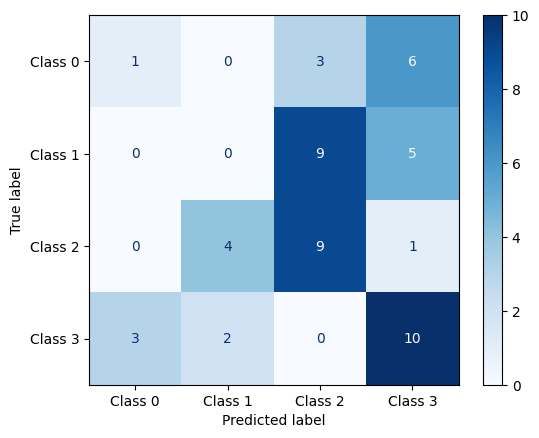

In [29]:
#Confusion Matrix work... There's clearly an error here.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

y_pred = model.predict(X_test)
#print(y_pred)

y_pred_better = []
for i in y_pred:
  y_pred_better.append(determiner(i))
print(y_pred_better)
print(type(y_pred))
print(type(y_test))

# I need to create a funciton to determine which outcome the prediction chooeses.
print(y_test)

# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_better)
# The resulting matrix 'cm' is a NumPy array

# 3. Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


Notes:


*   It seems like the CNN is always guessing 3. We should look into approaches to change this. (more data, more even representation of the 4 data types, more epochs are a couple of ideas.)
*   It looks like I got the augmentations to work, but it feels like a black box. I need to dig into the documentation to find out how much it is enlarging our training set.


*    31 labeled 0, 43 labeled 1, 42 labeled 2, 89 labeled 89





In [ ]:
89/205

0.43414634146341463